# Signal Transformations (Continuous)

In [1]:
# Course utilities (do not modify this cell)
# Generated by post-canvas-notebooks. Edits above the marker are overwritten.
from pathlib import Path
import sys


def _find_courseutils():
    """Find courseutils no matter where the course repo was cloned."""
    here = Path.cwd().resolve()

    for parent in [here] + list(here.parents):
        for candidate in (parent / "courseutils",
                          parent / "Signals_and_Systems" / "courseutils"):
            if (candidate / "basic_material.py").is_file():
                return candidate.resolve()

    raise FileNotFoundError(
        "Could not find the 'courseutils' folder. Clone "
        "https://github.com/mit-acl/Signals_and_Systems and run this "
        "notebook from inside the cloned repository, then restart the kernel."
    )


COURSEUTILS_DIR = _find_courseutils()

# courseutils is used both as a folder of modules and as a package,
# since control_materials does "import courseutils.basic_material",
# so the folder and its parent both go on the path.
for _location in (COURSEUTILS_DIR.parent, COURSEUTILS_DIR):
    if str(_location) not in sys.path:
        sys.path.insert(0, str(_location))

for _folder in ("data", "figs"):
    Path(_folder).mkdir(exist_ok=True)

# --- end course setup ---

import csv

import basic_material as bm
bm.setup_environment()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sympy import oo, Symbol, integrate, exp, Heaviside, plot, sin, cos, Piecewise, printing, lambdify
from sympy.abc import t, x
from sympy.interactive import init_printing
init_printing(pretty_print=True)

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## Motivation

**Goal:** analyze the impact of a transformation of the form $e(t) \to e(a t + b)$ on a signal (continuous or discrete) for various positive/negative $a$ and $b$

* $a$ acts as a **scaling on time** ($a > 1$ increases the value of $at$ compared to $t$ and thus has the effect of horizontally shrinking the signal plot). Note that negative $a$ leads to a time reversal.
* $b$ acts as **shift on time** ($b > 0$ shifts to the left) 

Relatively straight forward when only one of $a$ or $b$ are present, but some care required when both appear.
</font>

## General Form

The most general form of transformation of interest is $$y(t) = Dx(A(t-B)+C)$$ in which case 
$D$ only changes the amplitude and the remaining **order of operations** are: 
First shift by $C$, then scale by $A$, finally, shift by $B$. 

Clearly we can combine these parameters and rewrite the transformation as:
$$
y(t) = Dx(A(t-B + C/A))
$$
with the interpretation: First scale by $A$; then shift by $-B + C/A$ 

Similarly we could write the transformation as
$$
y(t) = Dx(At- AB + C)
$$
with the interpretation: First shift by $- AB + C$ and then scale by $A$. 

For the examples below, this means $e(at+b)$ can be viewed either as shifting by $b$ and then scaling by $a$, or, when $a \neq 0$, as scaling by $a$ and then shifting by $b/a$.

If we did it right, <span style="color:blue"> <b> all three of these should be identical</b></span>.
</font>

## Some examples to consider

In [3]:
# time variable for plotting
tt_vals = np.linspace(-1.5*np.pi, 1.5*np.pi, 1000)

#define some transform parameters t -> a*t+b
a = 2 # example time scaling
b = 1 # example time shift

# function to scale
e = cos(2*t)+0.5*sin(2*t)+sin(0.5*t)

# compute the shifted function
e_transformed = e.subs(t,a*t+b)

In [4]:
def shift_and_plot(e, a = 1, b = 0, Nskip = 20):
    # compute the shifted function
    e_transformed = e.subs(t,a*t+b)
    e_f1 = e.subs(t,t+b)
    g1 = a*t
    h1 = e_f1.subs(t,g1)
    print(h1)

    # convert to simplify the plotting of the functions
    lam_e = lambdify(t, e, modules=['numpy'])
    lam_e_transformed = lambdify(t, e_transformed, modules=['numpy'])
    lam_e_f1 = lambdify(t, e_f1, modules=['numpy'])
    lam_h1 = lambdify(t, h1, modules=['numpy'])
    # time variable for plotting

    fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
    plt.plot(tt_vals, lam_e(tt_vals),'b',label='Signal')
   
    if b != 0:
        msgs = 'First shift '
        msgs += 'left' if b > 0 else 'right'
        msgs += f' by ${np.abs(b)}$'
        plt.plot(tt_vals, lam_e_f1(tt_vals),'g--',lw=2,label=msgs)
    
    if np.isclose(a, 0):
        add_str="Constant signal"
    elif 0 < a < 1:
        add_str="Time dilation"
    elif -1 < a < 0:
        add_str="Time flipped dilation"
    elif 1 < a :
        add_str="Time contraction"
    elif a < -1:
        add_str="Time flipped contraction"
    elif np.isclose(a, -1):
        add_str="Time flipped"
    else:
        add_str=""
    scale_str = "" if np.isclose(a, 0) else rf" by ${1/np.abs(a):1.1f}$"
    plt.plot(tt_vals[0::Nskip], lam_h1(tt_vals[0::Nskip]),'co',lw=0.5,ms=4,label=add_str + scale_str)
    plt.plot(tt_vals, lam_e_transformed(tt_vals),'r-',lw=1,label='Transformed signal')

    plt.ylabel("Signal")
    plt.xlabel("Time")
    major_xticks = np.arange(-4, 5, 1)
    plt.xlim(-4.5,4.5)
    plt.tick_params(axis = 'both', which = 'major', labelsize = 12)
    plt.xticks(major_xticks)
    plt.grid(True)
    plt.legend()
    plt.title('Shift by $b = '+str(b)+'$ then scale $a = '+str(a)+'$ '+add_str)
    plt.annotate("cyan dotted \nshould be \nsame as red", xy=(2, -2))
    plt.show()

## Scale Up

sin(0.25*t) + 0.5*sin(1.0*t) + cos(1.0*t)


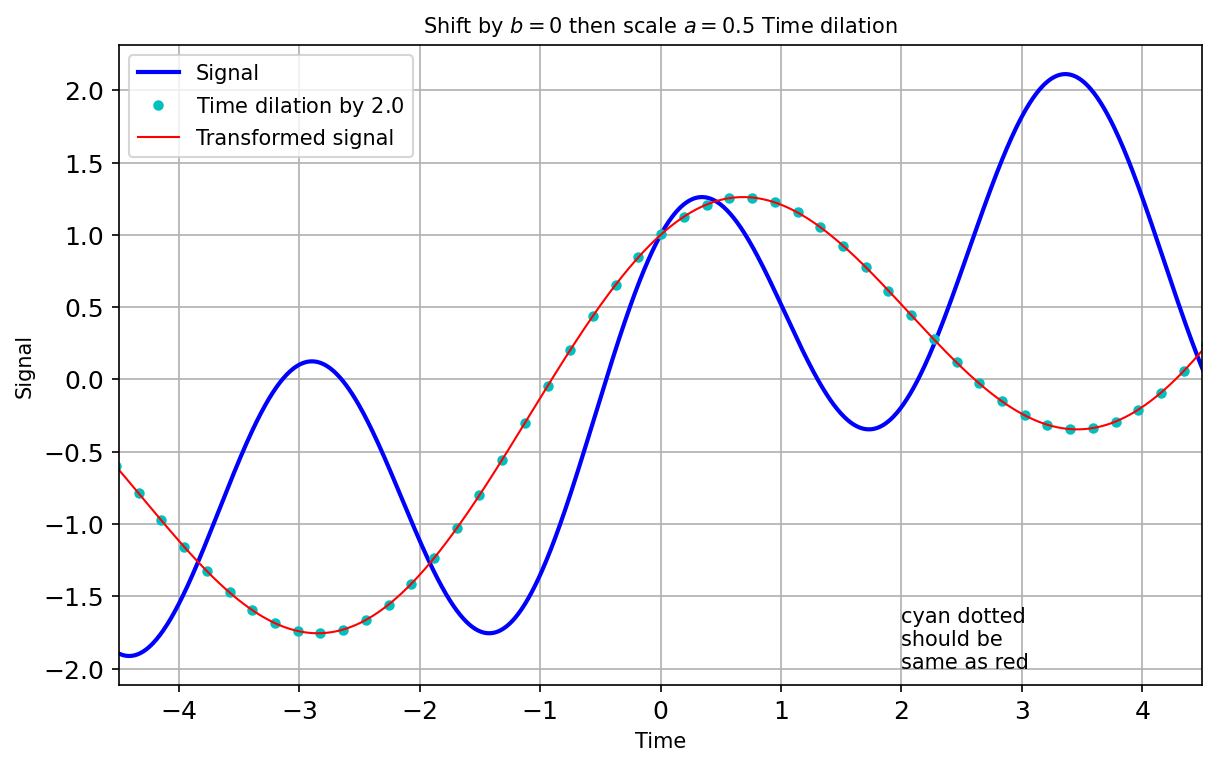

In [5]:
#define some transform parameters t -> a*t+b
a = 0.5 # time scaling
b = 0 # time shift
shift_and_plot(e, a, b)

**Note**: that $a < 1$ expands the signal (dilation)

### Negative Time Shift

sin(0.55*t - 0.5) + 0.5*sin(2.2*t - 2) + cos(2.2*t - 2)


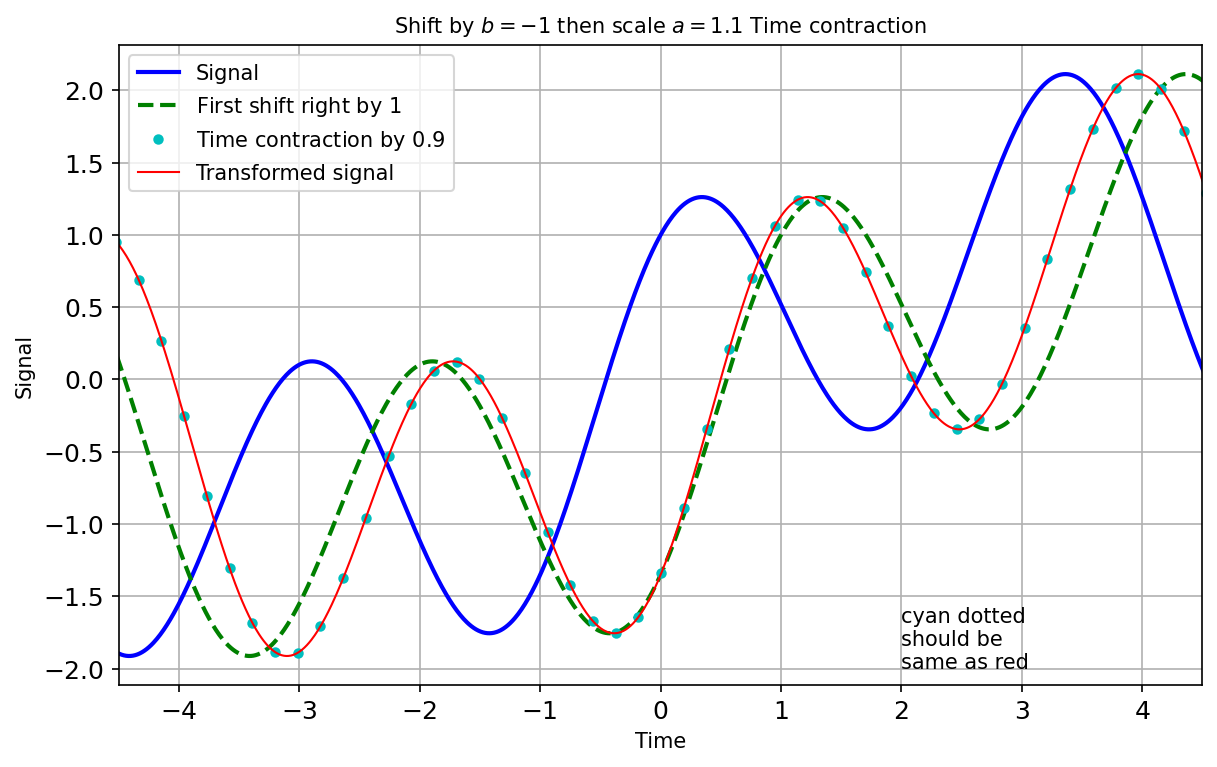

In [6]:
#define some transform parameters t -> a*t+b
a = 1.1 # time scaling
b = -1 # time shift
shift_and_plot(e, a, b)

**Note**: that $b < 0$ shifts signal to the right ("it happens later")

### Time Reversal

-sin(1.0*t) - 0.5*sin(4*t) + cos(4*t)


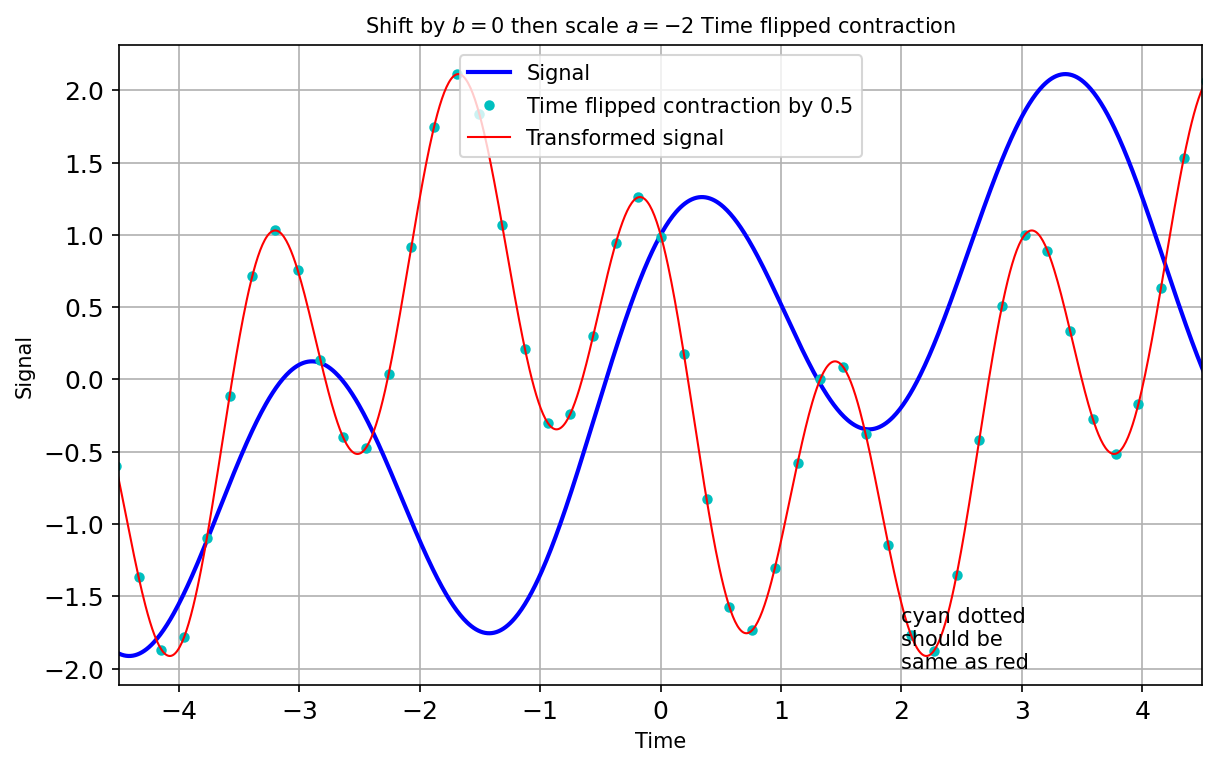

In [7]:
#define some transform parameters t -> a*t+b
a = -2 # time scaling
b = 0 # time shift
shift_and_plot(e, a, b)

**Note**: that $a < 0$ "scales and flips" the signal about the $t = 0$ axis.

## Combining All Negatives

-sin(1.0*t + 0.5) - 0.5*sin(4*t + 2) + cos(4*t + 2)


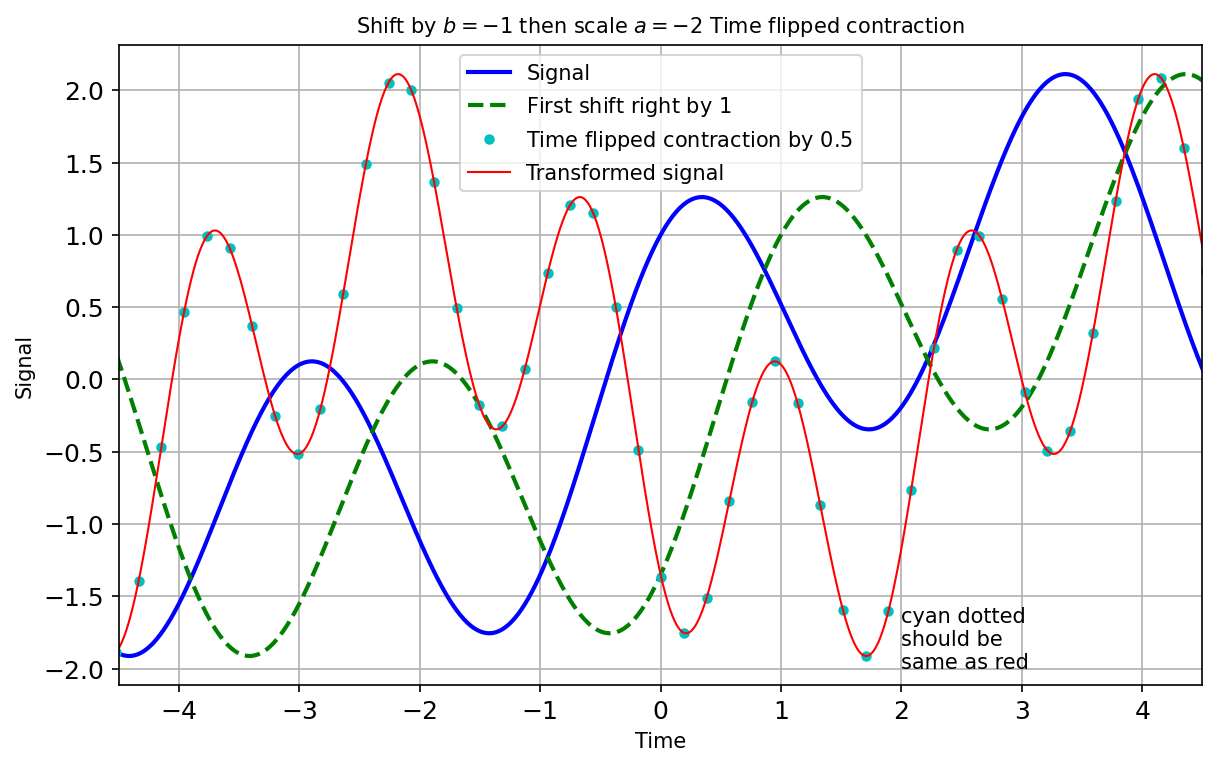

In [8]:
#define some transform parameters t -> a*t+b
a = -2 # time scaling
b = -1 # time shift
shift_and_plot(e, a, b)

**Note**: Shift right first, then scale down and flip. 

## Important Future Case ($t \to 2-t$)

-sin(0.5*t - 1.0) - 0.5*sin(2*t - 4) + cos(2*t - 4)


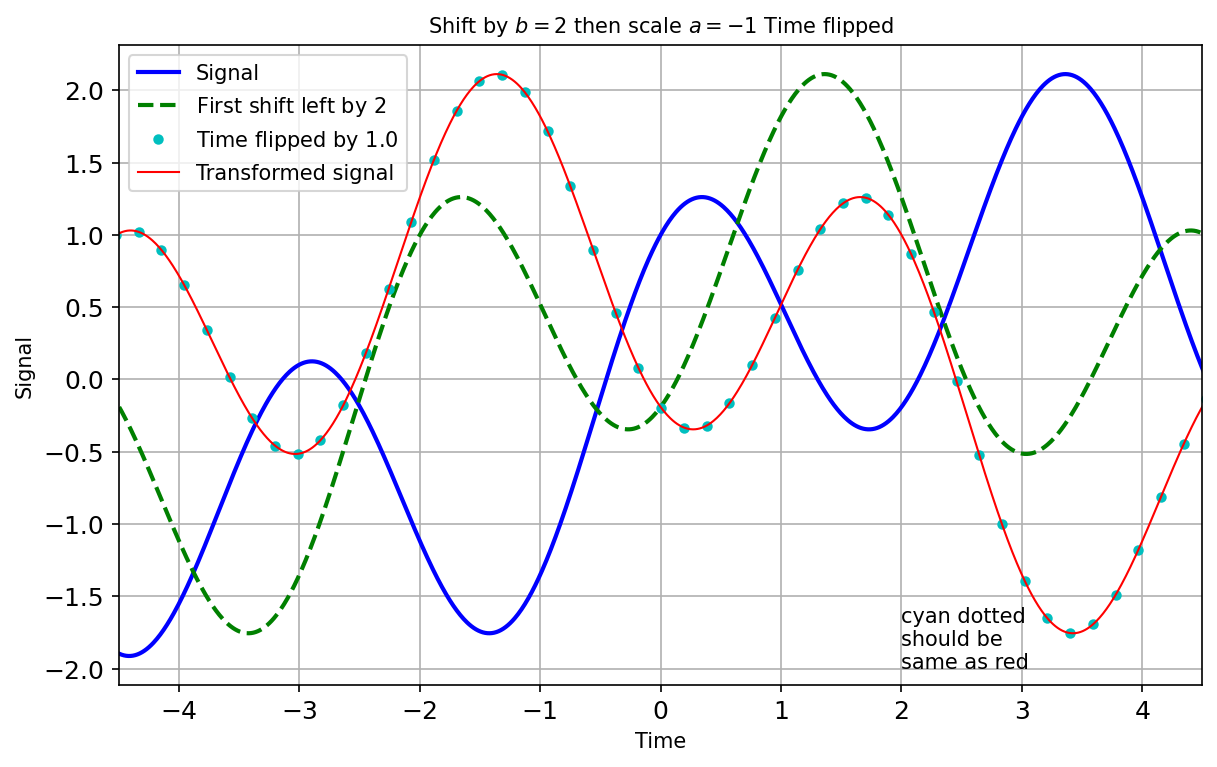

In [9]:
#define some transform parameters t -> a*t+b
a = -1 # time scaling
b = 2 # time shift
# function to scale
shift_and_plot(e, a, b)

# Can also consider this as compositions of functions

### Transformation Approach #1
* Consider the full transformation $t \to at + b$ as the composition of 2 steps
$ h_1(t) = f_1(g_1(t))$

* Here $f_1(t) = e(t + b)$ (shift by $b$) and $g_1(t) = at$ (scale by $a$) so that $$h_1(t) = f_1(g_1(t)) = f_1(at) = e(at + b)$$ 

* Now consider the transforms of the signal $e(t)$ through these components $f_1$ and $g_1$
    

In [10]:
#define some transform parameters t -> a*t+b
a = -2 # example time scaling
b = -1 # example time shift

# function to scale
e = cos(2*t)+0.5*sin(2*t)+sin(0.5*t)
# compute the shifted function
e_transformed = e.subs(t,a*t+b)

In [11]:
# compute the two parts f1 and g1
f1 = e.subs(t,t+b)
g1 = a*t
h1 = f1.subs(t,g1)

In [12]:
# convert to simplify the plotting of the functions
lam_e = lambdify(t, e, modules=['numpy'])
lam_e_transformed = lambdify(t, e_transformed, modules=['numpy'])
lam_e_f1 = lambdify(t, f1, modules=['numpy'])
lam_h1 = lambdify(t, h1, modules=['numpy'])

To manually implement these steps, process is to first shift by $b$ ($f_1$) and then scale by $a$ which is ($g_1$) - including time reversal if $a < 0$  


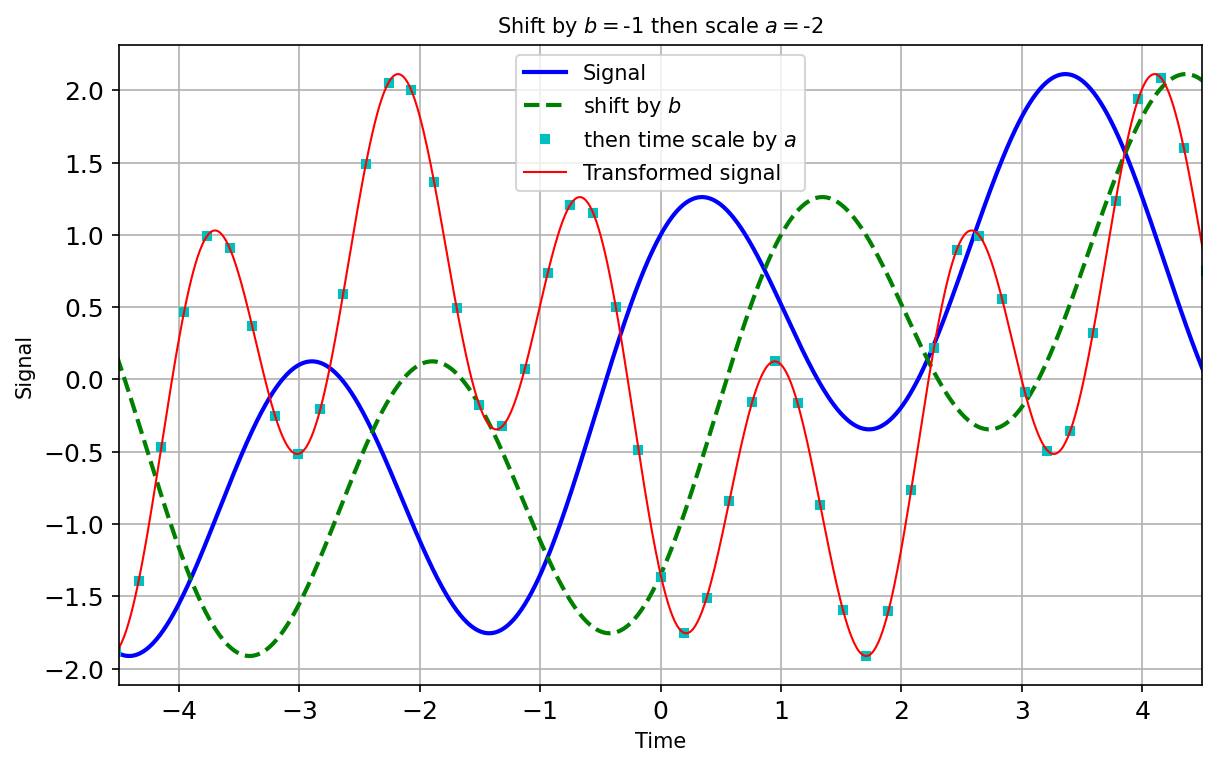

In [13]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(tt_vals, lam_e(tt_vals),'b',label='Signal')
plt.plot(tt_vals, lam_e_f1(tt_vals),'g--',label='shift by $b$')
plt.plot(tt_vals[0::20], lam_h1(tt_vals[0::20]),'cs',ms=4,label='then time scale by $a$')
plt.plot(tt_vals, lam_e_transformed(tt_vals),'r-',lw=1,label='Transformed signal')

plt.ylabel("Signal")
plt.xlabel("Time")
major_xticks = np.arange(-4, 5, 1)
plt.xlim(-4.5,4.5)
plt.tick_params(axis = 'both', which = 'major', labelsize = 12)
plt.xticks(major_xticks)
plt.grid(True)
plt.legend()
plt.title('Shift by $b = $'+str(b)+' then scale $a = $'+str(a))
plt.show()

### If right, should expect to see that the cyan dotted line is the same as the red one

## Transformation Approach #2

* Consider the full transformation as the composition of two different steps:

$$
h_2(t) = f_2(g_2(t)).
$$

* When $a \neq 0$, define $f_2(t) = e(at)$ and $g_2(t) = t+b/a$. Then

$$
h_2(t) = f_2(t+b/a) = e(a(t+b/a)) = e(at+b).
$$

* Thus this approach is: first form the time-scaled signal $f_2(t)$, then shift that result by $b/a$.

* If $a=0$, then $e(at+b)=e(b)$ is a constant signal and the $b/a$ shift is not defined.

In [14]:
# Evaluate signal for scaled t
f2 = e.subs(t,a*t)

if np.isclose(a, 0):
    g2 = t
    h2 = e_transformed
    b_over_a_str = "not defined"
else:
    g2 = t+b/a
    # evaluate the scaled-t signal for shifted time
    h2 = f2.subs(t,g2)
    b_over_a_str = f"{b/a:1.2f}"

lam_f2 = lambdify(t, f2, modules=['numpy'])
lam_h2 = lambdify(t, h2, modules=['numpy'])

* Manual implementation: compute $f_2(t)=e(at)$ first, then evaluate it at $t+b/a$ when $a \neq 0$.

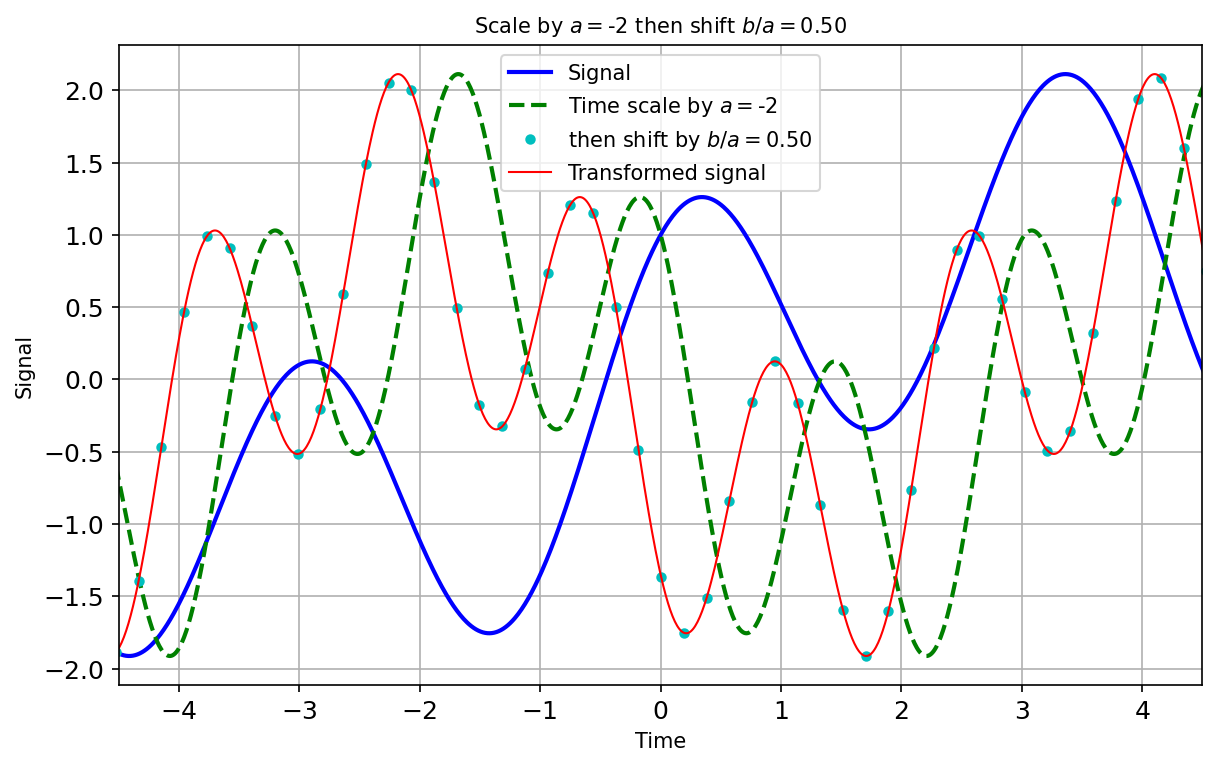

In [15]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(tt_vals, lam_e(tt_vals),'b',label='Signal')
plt.plot(tt_vals, lam_f2(tt_vals),'g--',label='Time scale by $a = $'+str(a))
plt.plot(tt_vals[0::20], lam_h2(tt_vals[0::20]),'co',ms=4,label='then shift by $b/a = $'+b_over_a_str)
plt.plot(tt_vals, lam_e_transformed(tt_vals),'r-',lw=1,label='Transformed signal')

plt.ylabel("Signal")
plt.xlabel("Time")
major_xticks = np.arange(-4, 5, 1)
plt.xlim(-4.5,4.5)
plt.tick_params(axis = 'both', which = 'major', labelsize = 12)
plt.xticks(major_xticks)
plt.grid(True)
plt.title('Scale by $a = $'+str(a)+' then shift $b/a = $'+b_over_a_str)
plt.legend()
plt.show()

### If right, should expect to see that the cyan dotted line is the same as the red one

### Summary

For $e(at+b)$, the two equivalent constructions are:

$$
e(at+b) = f_1(at), \qquad f_1(t)=e(t+b)
$$

so: shift by $b$, then scale by $a$.

For $a\neq 0$,

$$
e(at+b)=f_2\left(t+\frac{b}{a}\right), \qquad f_2(t)=e(at)
$$

so: scale by $a$, then shift by $b/a$.

When $a=0$, the signal becomes the constant $e(b)$.